In [1]:
import scanpy as sc
import pandas as pd
import numpy as np

STDOUT:
 
STDERR:
 
Return code: 0


/home/gzu5140/.conda/envs/grnboost310/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


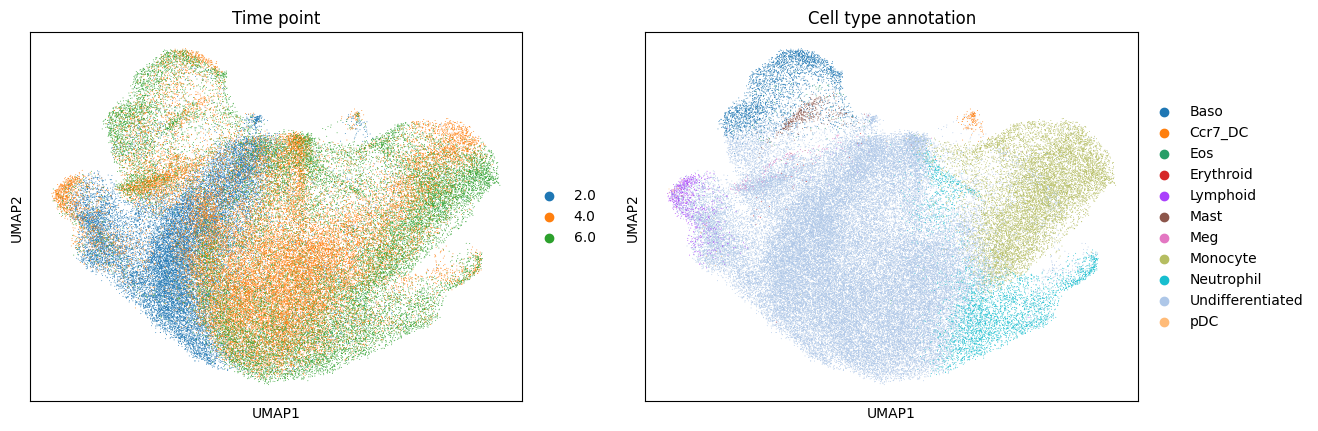

In [2]:
import subprocess
from pathlib import Path

repo = Path("/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER")

cmd = """
module load git-lfs
git lfs pull --include=real_data/LSK_d2_d4_d6.h5ad
"""

result = subprocess.run(
    ["bash", "-lc", cmd],
    cwd=repo,
    capture_output=True,
    text=True,
)

print("STDOUT:\n", result.stdout)
print("STDERR:\n", result.stderr)
print("Return code:", result.returncode)

adata_path = "/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/real_data/LSK_d2_d4_d6.h5ad"
adata = sc.read_h5ad(adata_path)
adata.obs_names_make_unique()
# Plot UMAP
sc.pl.umap(adata, color=['Time point', 'Cell type annotation'])

In [3]:
import pandas as pd

df = pd.read_excel(
    "/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/TwINFER_verification/Mouse_TFs_Kinases_webpage-3-30-2017.xlsx",
    header=None,
    index_col=None
)

# first non-empty row = real header
header_row = df.dropna(how="all").index[0]

# set column names
df.columns = df.loc[header_row].astype(str)

# drop header row and empty rows
all_gene_list_TF = (
    df
    .iloc[header_row + 1 :]
    .dropna(how="all")
    .reset_index(drop=True)
)

gene_TF = all_gene_list_TF['Gene Symbol']

ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

In [4]:
#Check that all of these genes are present in the dataset (since sometimes they have alternate names. E.g. Pu1 is names Spi1)
gene_list_check = gene_TF

all_genes = {g.lower() for g in adata.var_names}
gene_list_check =  [g.lower() for g in gene_list_check]
found = [a for a in gene_list_check if a in all_genes]
not_found = [a for a in gene_list_check if a not in all_genes]
print(f"Found {len(found)} genes out of {len(gene_list_check)}")
if found:
    print("✅ Found gene(s):", found)
print("❌ Not found in dataset", not_found)

Found 1400 genes out of 1482
✅ Found gene(s): ['adnp', 'aebp2', 'aff1', 'aff2', 'aff3', 'aff4', 'ahr', 'ahrr', 'ai987944', 'aire', 'alx1', 'alx3', 'alx4', 'ar', 'arid1a', 'arid1b', 'arid2', 'arid3a', 'arid3b', 'arid3c', 'arid4a', 'arid4b', 'arid5a', 'arid5b', 'arnt', 'arnt2', 'arntl', 'arntl2', 'arx', 'ascl1', 'ascl2', 'ascl3', 'ascl4', 'ascl5', 'atf1', 'atf2', 'atf3', 'atf4', 'atf5', 'atf6', 'atf6b', 'atf7', 'atf7', 'atoh1', 'atoh7', 'atoh8', 'au041133', 'aw146154', 'aw822073', 'bach1', 'bach2', 'barhl1', 'barhl2', 'barx1', 'barx2', 'batf', 'batf2', 'batf3', 'baz2b', 'bbx', 'bc025920', 'bcl11a', 'bcl11b', 'bcl6', 'bcl6b', 'bhlha15', 'bhlha9', 'bhlhe22', 'bhlhe23', 'bhlhe40', 'bhlhe41', 'bnc2', 'bsx', 'c030039l03rik', 'camta1', 'camta2', 'carhsp1', 'cbfb', 'cdc5l', 'cdip1', 'cdx1', 'cdx2', 'cdx4', 'cebpa', 'cebpb', 'cebpe', 'cebpg', 'cers2', 'cers3', 'cers4', 'cers5', 'cers6', 'cic', 'clock', 'cphx1', 'cphx2', 'cphx3', 'creb1', 'creb3', 'creb3l1', 'creb3l2', 'creb3l3', 'creb3l4', 'creb

In [5]:
adata_day_2 = adata[adata.obs['Time point'] == 2].copy()
sc.pp.filter_genes(adata_day_2, min_cells=10)

all_genes = {g.lower() for g in adata_day_2.var_names}
gene_list_check =  [g.lower() for g in gene_list_check]
found_day_2 = [a for a in gene_list_check if a in all_genes]
not_found = [a for a in gene_list_check if a not in all_genes]
print(f"Found {len(found_day_2)} genes out of {len(gene_list_check)}")
if found:
    print("✅ Found gene(s):", found)

print("❌ Not found in dataset", not_found)

Found 904 genes out of 1482
✅ Found gene(s): ['adnp', 'aebp2', 'aff1', 'aff2', 'aff3', 'aff4', 'ahr', 'ahrr', 'ai987944', 'aire', 'alx1', 'alx3', 'alx4', 'ar', 'arid1a', 'arid1b', 'arid2', 'arid3a', 'arid3b', 'arid3c', 'arid4a', 'arid4b', 'arid5a', 'arid5b', 'arnt', 'arnt2', 'arntl', 'arntl2', 'arx', 'ascl1', 'ascl2', 'ascl3', 'ascl4', 'ascl5', 'atf1', 'atf2', 'atf3', 'atf4', 'atf5', 'atf6', 'atf6b', 'atf7', 'atf7', 'atoh1', 'atoh7', 'atoh8', 'au041133', 'aw146154', 'aw822073', 'bach1', 'bach2', 'barhl1', 'barhl2', 'barx1', 'barx2', 'batf', 'batf2', 'batf3', 'baz2b', 'bbx', 'bc025920', 'bcl11a', 'bcl11b', 'bcl6', 'bcl6b', 'bhlha15', 'bhlha9', 'bhlhe22', 'bhlhe23', 'bhlhe40', 'bhlhe41', 'bnc2', 'bsx', 'c030039l03rik', 'camta1', 'camta2', 'carhsp1', 'cbfb', 'cdc5l', 'cdip1', 'cdx1', 'cdx2', 'cdx4', 'cebpa', 'cebpb', 'cebpe', 'cebpg', 'cers2', 'cers3', 'cers4', 'cers5', 'cers6', 'cic', 'clock', 'cphx1', 'cphx2', 'cphx3', 'creb1', 'creb3', 'creb3l1', 'creb3l2', 'creb3l3', 'creb3l4', 'crebz

In [6]:
adata_day_4 = adata[adata.obs['Time point'] == 4].copy()
sc.pp.filter_genes(adata_day_4, min_cells=10)
gene_list_check = gene_TF
all_genes = {g.lower() for g in adata_day_4.var_names}
gene_list_check =  [g.lower() for g in gene_list_check]
found_day_4 = [a for a in gene_list_check if a in all_genes]
not_found = [a for a in gene_list_check if a not in all_genes]
print(f"Found {len(found_day_4)} genes out of {len(gene_list_check)}")
if found:
    print("✅ Found gene(s):", found_day_4)

print("❌ Not found in dataset", not_found)

Found 943 genes out of 1482
✅ Found gene(s): ['adnp', 'aebp2', 'aff1', 'aff2', 'aff4', 'ahr', 'ahrr', 'ai987944', 'aire', 'alx4', 'ar', 'arid1a', 'arid1b', 'arid2', 'arid3a', 'arid3b', 'arid3c', 'arid4a', 'arid4b', 'arid5a', 'arid5b', 'arnt', 'arnt2', 'arntl', 'arntl2', 'arx', 'ascl4', 'atf1', 'atf2', 'atf3', 'atf4', 'atf5', 'atf6', 'atf6b', 'atf7', 'atf7', 'atoh8', 'au041133', 'aw146154', 'bach1', 'bach2', 'barhl1', 'barhl2', 'batf', 'batf2', 'batf3', 'baz2b', 'bbx', 'bc025920', 'bcl11a', 'bcl11b', 'bcl6', 'bcl6b', 'bhlha15', 'bhlhe40', 'bhlhe41', 'c030039l03rik', 'camta1', 'camta2', 'carhsp1', 'cbfb', 'cdc5l', 'cdip1', 'cebpa', 'cebpb', 'cebpe', 'cebpg', 'cers2', 'cers4', 'cers5', 'cers6', 'cic', 'clock', 'creb1', 'creb3', 'creb3l1', 'creb3l2', 'creb3l4', 'crebzf', 'crem', 'crx', 'csdc2', 'csde1', 'ctcf', 'cux1', 'd3ertd254e', 'dbp', 'ddit3', 'deaf1', 'dlx1', 'dlx6', 'dmbx1', 'dmrta2', 'dmtf1', 'dnajc1', 'dnajc2', 'e2f1', 'e2f2', 'e2f3', 'e2f4', 'e2f5', 'e2f6', 'e2f7', 'e2f8', 'e4300

In [7]:
adata_day_6 = adata[adata.obs['Time point'] == 6].copy()
sc.pp.filter_genes(adata_day_6, min_cells=10)

gene_list_check = gene_TF

all_genes = {g.lower() for g in adata_day_6.var_names}
gene_list_check =  [g.lower() for g in gene_list_check]
found_day_6 = [a for a in gene_list_check if a in all_genes]
not_found = [a for a in gene_list_check if a not in all_genes]
print(f"Found {len(found_day_6)} genes out of {len(gene_list_check)}")
if found:
    print("✅ Found gene(s):", found_day_6)

print("❌ Not found in dataset", not_found)

Found 944 genes out of 1482
✅ Found gene(s): ['adnp', 'aebp2', 'aff1', 'aff2', 'aff4', 'ahr', 'ahrr', 'ai987944', 'alx4', 'ar', 'arid1a', 'arid1b', 'arid2', 'arid3a', 'arid3b', 'arid3c', 'arid4a', 'arid4b', 'arid5a', 'arid5b', 'arnt', 'arnt2', 'arntl', 'arntl2', 'arx', 'ascl2', 'ascl4', 'atf1', 'atf2', 'atf3', 'atf4', 'atf5', 'atf6', 'atf6b', 'atf7', 'atf7', 'au041133', 'aw146154', 'bach1', 'bach2', 'barhl1', 'batf', 'batf2', 'batf3', 'baz2b', 'bbx', 'bc025920', 'bcl11a', 'bcl11b', 'bcl6', 'bhlha15', 'bhlhe40', 'bhlhe41', 'c030039l03rik', 'camta1', 'camta2', 'carhsp1', 'cbfb', 'cdc5l', 'cdip1', 'cebpa', 'cebpb', 'cebpe', 'cebpg', 'cers2', 'cers4', 'cers5', 'cers6', 'cic', 'clock', 'creb1', 'creb3', 'creb3l1', 'creb3l2', 'creb3l3', 'creb3l4', 'crebzf', 'crem', 'crxos', 'csdc2', 'csde1', 'ctcf', 'cux1', 'cux2', 'd3ertd254e', 'dbp', 'ddit3', 'deaf1', 'dlx1', 'dlx6', 'dmrt2', 'dmrta2', 'dmtf1', 'dnajc1', 'dnajc2', 'e2f1', 'e2f2', 'e2f3', 'e2f4', 'e2f5', 'e2f6', 'e2f7', 'e2f8', 'e430018j23r

In [8]:
continuously_expressed_genes = set(found_day_2).intersection(set(found_day_4)).intersection(set(found_day_6))
len(continuously_expressed_genes)

868

In [9]:
#Gene set to use for current analysis
gene_set_name = "all_TF" #For Neutrophils, modify this to Neutrophil
curr_gene_list = list(continuously_expressed_genes)
gene_subset = [s + '_mRNA' for s in curr_gene_list]

In [10]:
present_tfs = [tf for tf in gene_subset if tf in adata_day_2.var_names]
adata_day_2.var_names.to_list()


['0610007P14Rik',
 '0610009B22Rik',
 '0610009E02Rik',
 '0610009L18Rik',
 '0610009O20Rik',
 '0610010F05Rik',
 '0610010K14Rik',
 '0610011F06Rik',
 '0610012D04Rik',
 '0610012G03Rik',
 '0610030E20Rik',
 '0610031O16Rik',
 '0610037L13Rik',
 '0610038B21Rik',
 '0610040B10Rik',
 '0610040J01Rik',
 '1110001J03Rik',
 '1110002L01Rik',
 '1110004E09Rik',
 '1110004F10Rik',
 '1110008F13Rik',
 '1110008L16Rik',
 '1110008P14Rik',
 '1110012L19Rik',
 '1110019D14Rik',
 '1110020A21Rik',
 '1110028F11Rik',
 '1110032A03Rik',
 '1110032F04Rik',
 '1110034G24Rik',
 '1110037F02Rik',
 '1110038B12Rik',
 '1110038F14Rik',
 '1110046J04Rik',
 '1110051M20Rik',
 '1110059E24Rik',
 '1110059G10Rik',
 '1110065P20Rik',
 '1190002N15Rik',
 '1190005I06Rik',
 '1190007I07Rik',
 '1300002E11Rik',
 '1500004A13Rik',
 '1500009L16Rik',
 '1500011B03Rik',
 '1500011K16Rik',
 '1500017E21Rik',
 '1500026H17Rik',
 '1600002H07Rik',
 '1600002K03Rik',
 '1600010M07Rik',
 '1600012H06Rik',
 '1600014C10Rik',
 '1600014C23Rik',
 '1600020E01Rik',
 '1600029O

In [20]:
adata_day_2.var['gene_symbols'] = adata_day_2.var.index
adata_day_2.var['gene_symbols']

0610007P14Rik    0610007P14Rik
0610009B22Rik    0610009B22Rik
0610009E02Rik    0610009E02Rik
0610009L18Rik    0610009L18Rik
0610009O20Rik    0610009O20Rik
                     ...      
mt-Nd3                  mt-Nd3
mt-Nd4                  mt-Nd4
mt-Nd4l                mt-Nd4l
mt-Nd5                  mt-Nd5
mt-Nd6                  mt-Nd6
Name: gene_symbols, Length: 14078, dtype: object

In [11]:
import scanpy as sc
import pandas as pd
import numpy as np

adata_genes_upper = adata_day_2.var_names.str.upper()

curr_genes_upper = pd.Series(curr_gene_list).str.upper()

present_mask = curr_genes_upper.isin(adata_genes_upper.values)

present_tfs = adata_day_2.var_names[
    adata_genes_upper.isin(curr_genes_upper)
].tolist()

print(len(present_tfs))

868


In [ ]:
from scipy import sparse
import numpy as np
import pandas as pd

if not present_tfs:
    print("None of the TFs in the provided list were found in the AnnData object.")
else:
    adata_tfs = adata_day_2[:, present_tfs]

    # Mean per gene (cells × genes → axis=0)
    if sparse.issparse(adata_tfs.X):
        mean_expression = np.asarray(adata_tfs.X.mean(axis=0)).ravel()
    else:
        mean_expression = adata_tfs.X.mean(axis=0)

    expression_df = pd.DataFrame({
        "Gene": adata_tfs.var_names,
        "MeanExpression": mean_expression
    })

    expression_df.sort_values("MeanExpression", ascending=False, inplace=True)

    top_100_tfs = expression_df.head(100)

    print("Top 100 highly expressed TFs:")
    print(top_100_tfs["Gene"].tolist())


Top 100 highly expressed TFs:
['Ybx1', 'Ttf1', 'Hmgb1', 'Ybx3', 'Nfkb1', 'Hmgb2', 'Srebf2', 'Smarce1', 'Csde1', 'Jund', 'Tsc22d1', 'Max', 'Sp1', 'Bcl11a', 'Irf9', 'Myc', 'Mef2c', 'Ssrp1', 'Tcf4', 'Cbfb', 'Trp53', 'Arid1a', 'Stat3', 'Sub1', 'Mta2', 'Xbp1', 'Cers2', 'Etv6', 'Ubtf', 'Ikzf1', 'Foxp1', 'Smarcc2', 'Dnajc2', 'Zmiz1', 'Nfe2l2', 'Gtf2i', 'Atf4', 'Sox4', 'Cdc5l', 'Zfp422', 'Usf2', 'Mta1', 'Gata2', 'Mafg', 'Creb1', 'Atf2', 'Klf6', 'Runx1', 'Mbd3', 'Rfx7', 'Litaf', 'Zbtb7a', 'Id2', 'Runx2', 'Cux1', 'Gm13139', 'Gatad1', 'Cebpb', 'Tulp3', 'Hmgb3', 'Runx3', 'Mbd1', 'Sp100', 'Zfp91', 'Ncor1', 'Pou2f2', 'Hbp1', 'Tfam', 'Elk3', 'Tcf3', 'Myb', 'Erg', 'Terf2', 'Satb1', 'Mbd2', 'Nfyb', 'Kat7', 'Smarcc1', 'Smad5', 'Patz1', 'Zfx', 'Gtf3a', 'Srebf1', 'Tfec', 'Id1', 'Aebp2', 'Stat1', 'Smad2', 'Sp110', 'Mef2d', 'Meis1', 'Spi1', 'Hmg20b', 'Nfatc3', 'Cebpg', 'Elf1', 'Jarid2', 'Gatad2b', 'Whsc1', 'Glmp']


In [15]:
%pip install scikit-misc

Note: you may need to restart the kernel to use updated packages.


In [19]:
sc.pp.highly_variable_genes(
    adata_tfs,
    n_top_genes=50
)

top_100_hvgs = adata_tfs.var_names[adata_tfs.var["highly_variable"]]
top_100_hvgs

Index(['2610305D13Rik', 'Ahr', 'Alx4', 'Arid1b', 'Arid4b', 'Arx', 'Bcl11b',
       'C030039L03Rik', 'Eomes', 'Etv1', 'Gata2', 'Hey1', 'Hivep3', 'Hmga2',
       'Hnf4a', 'Hsf4', 'Id2', 'Id3', 'Irf1', 'Irf4', 'Irf7', 'Irf8', 'Klf2',
       'Klf6', 'Lhx2', 'Mycn', 'Nr2f2', 'Nr4a3', 'Pbx1', 'Plagl1', 'Prdm10',
       'Prox2', 'Rsl1', 'Satb1', 'Six4', 'Snai1', 'Spib', 'Spic', 'Tcf7',
       'Tcf7l2', 'Tox', 'Tsc22d1', 'Tshz1', 'Ybx2', 'Zeb1', 'Zfp236', 'Zfp345',
       'Zfp551', 'Zfp74', 'Zfp85'],
      dtype='object')

### Grnboost

In [7]:
import pandas as pd
import scanpy as sc
import numpy as np
from arboreto.utils import load_tf_names
from arboreto.algo import grnboost2

In [2]:
import subprocess
from pathlib import Path

repo = Path("/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER")

cmd = """
module load git-lfs
git lfs pull --include=real_data/LSK_d2_d4_d6.h5ad
"""

result = subprocess.run(
    ["bash", "-lc", cmd],
    cwd=repo,
    capture_output=True,
    text=True,
)

print("STDOUT:\n", result.stdout)
print("STDERR:\n", result.stderr)
print("Return code:", result.returncode)


STDOUT:
 
STDERR:
 
Return code: 0


/home/gzu5140/.conda/envs/grnboost310/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


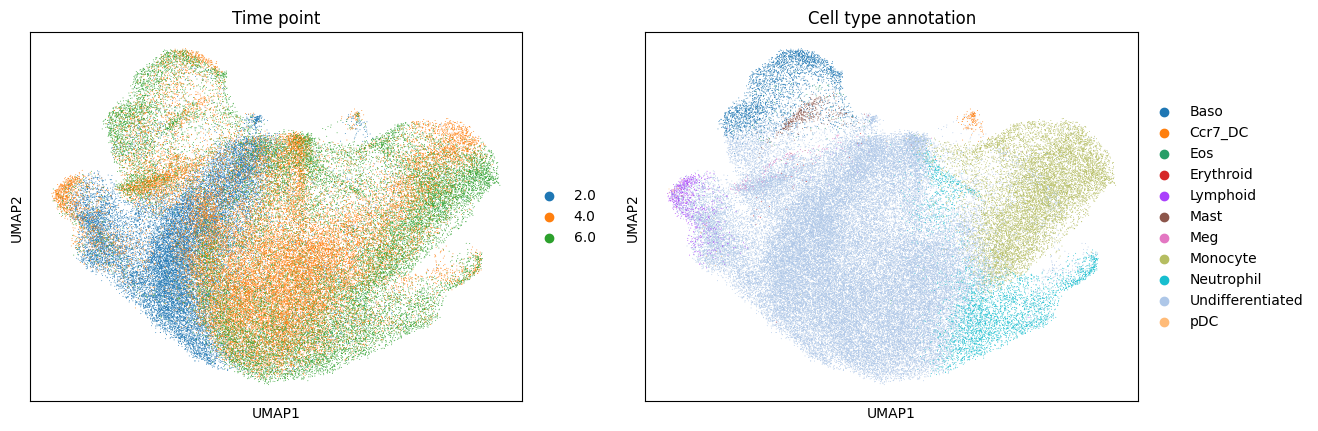

In [6]:
#Load the h5ad file
# Define the full path to the data file
path_to_code_repo = "/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/"
data_path = f"{path_to_code_repo}/real_data/"
file_path = f'{data_path}LSK_d2_d4_d6.h5ad'
adata = sc.read_h5ad(file_path)
adata.obs_names_make_unique()
# Plot UMAP
sc.pl.umap(adata, color=['Time point', 'Cell type annotation'])

In [7]:
adata.obs['cell_id'] = adata.obs.index
t1 = 2
curr_gene_list = ['Ybx1', 'Ttf1', 'Hmgb1', 'Ybx3', 'Nfkb1', 'Hmgb2', 'Srebf2', 'Smarce1', 'Csde1', 'Jund', 'Tsc22d1', 'Max', 'Sp1', 'Bcl11a', 'Irf9', 'Myc', 'Mef2c', 'Ssrp1', 'Tcf4', 'Cbfb', 'Trp53', 'Arid1a', 'Stat3', 'Sub1', 'Mta2', 'Xbp1', 'Cers2', 'Etv6', 'Ubtf', 'Ikzf1', 'Foxp1', 'Smarcc2', 'Dnajc2', 'Zmiz1', 'Nfe2l2', 'Gtf2i', 'Atf4', 'Sox4', 'Cdc5l', 'Zfp422', 'Usf2', 'Mta1', 'Gata2', 'Mafg', 'Creb1', 'Atf2', 'Klf6', 'Runx1', 'Mbd3', 'Rfx7']

adata_t1_all = adata[(adata.obs['Time point'] == t1)].copy()
# All cells at time t1 to calculate gene correlation
def make_all_cells_table(adata_t, timepoint, gene_subset, curr_gene_list):
    # add expression
    df = adata_t[:,curr_gene_list].X.toarray()

    return df

gene_subset = [s + '_mRNA' for s in curr_gene_list]
t1_data_all_cells = make_all_cells_table(
    adata_t1_all, t1, gene_subset, curr_gene_list
)

In [ ]:
import numpy as np
import pandas as pd

from arboreto.utils import load_tf_names
from arboreto.algo import grnboost2
from distributed import LocalCluster, Client


# ============================================================
# Utilities
# ============================================================

def shuffle_expression_matrix_columnwise(X, rng):
    """
    Independently permute each gene column.
    """
    X = np.asarray(X)
    Xs = np.empty_like(X)
    for j in range(X.shape[1]):
        Xs[:, j] = rng.permutation(X[:, j])
    return Xs


def run_one_null(i, X, gene_names, tf_names, seed, client):
    """
    Run a single shuffled GRNBoost2 null.
    """
    rng = np.random.default_rng(seed + i)
    X_null = shuffle_expression_matrix_columnwise(X, rng)

    net = grnboost2(
        expression_data=X_null,
        gene_names=gene_names,
        tf_names=tf_names,
        client_or_address=client,
        verbose=False,
        seed=seed + i,
    )
    net["shuffle"] = i
    return net


# ============================================================
# Main
# ============================================================

if __name__ == "__main__":

    # ------------------------------
    # Dask cluster
    # ------------------------------
    cluster = LocalCluster(
        n_workers=10,
        threads_per_worker=1,
        memory_limit="8GB",
        dashboard_address=None,   # avoids 8787 conflicts
    )
    client = Client(cluster)

    print(client)

    # ---- INPUTS (you already have these) ----
    X = t1_data_all_cells          # shape: (n_cells, n_genes)
    tf_names = list(curr_gene_list)
    gene_names = tf_names          # since you're restricting to TFs

    # ------------------------------
    # Real network (optional)
    # ------------------------------
    network_real = grnboost2(
        expression_data=X,
        gene_names=gene_names,
        tf_names=tf_names,
        client_or_address=client,
        seed=0,
        verbose=True,
    )

    # # ------------------------------
    # # Null shuffles
    # # ------------------------------
    # n_shuffles = 1000
    # seed = 42

    # null_networks = []
    # for i in range(n_shuffles):
    #     net = run_one_null(
    #         i,
    #         X,
    #         gene_names,
    #         tf_names,
    #         seed,
    #         client,
    #     )
    #     null_networks.append(net)

    #     if (i + 1) % 50 == 0:
    #         print(f"Completed {i + 1}/{n_shuffles} nulls")

    # # ------------------------------
    # # Aggregate null distribution
    # # ------------------------------
    # null_df = pd.concat(null_networks, ignore_index=True)
    # # null_df.to_csv(
    # #     "output_nulls.tsv",
    # #     sep="\t",
    # #     index=False,
    # #     header=False,
    # # )

    # global_null = null_df["importance"].to_numpy()

    # thresholds = {
    #     p: np.percentile(global_null, p)
    #     for p in (95, 99, 99.5, 99.9)
    # }

    # print("Null thresholds:")
    # for p, t in thresholds.items():
    #     print(f"{p}%: {t:.6g}")

    # # ------------------------------
    # # Cleanup
    # # ------------------------------
    # client.close()
    # cluster.close()

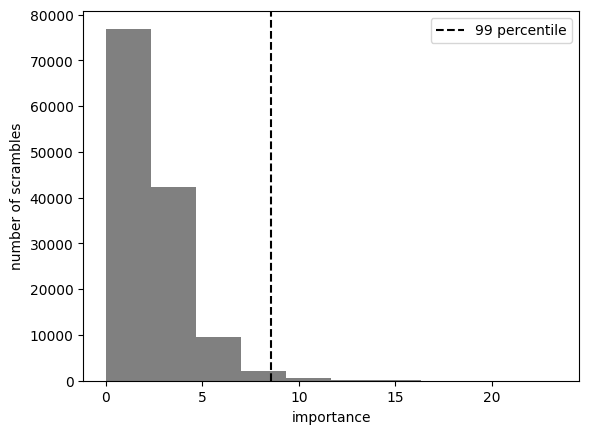

In [58]:
plt.hist(global_null, color = "gray")
plt.axvline(np.percentile(global_null, 99), label = "99 percentile", linestyle = "--", color = "black")
plt.xlabel('importance')
plt.ylabel('number of scrambles')
plt.legend()
plt.show()

In [7]:
tf_names = list(curr_gene_list)

network = grnboost2(
    expression_data=t1_data_all_cells,
    gene_names=tf_names,
    tf_names=tf_names,
    verbose=True,
)

preparing dask client
parsing input
creating dask graph
4 partitions
computing dask graph
shutting down client and local cluster
finished


In [17]:
stable_edges = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/gene_correlation_inference_LARRY.csv")
gene_list = []
for row_list in stable_edges.iterrows():
    row = row_list[1]
    gene_pair = (row['gene_1'], row['gene_2'])
    rev_gene_pair = (row['gene_2'], row['gene_1'])
    gene_list.append(gene_pair)
    gene_list.append(rev_gene_pair)
all_interactions = pd.DataFrame(gene_list, columns = ['gene_1', 'gene_2'])

In [ ]:
inferred_interactions = pd.merge(
    all_interactions,
    network,
    left_on=["gene_1", "gene_2"],
    right_on=["TF", "target"],
    how="inner"   # or "left", depending on intent
).sort_values(by = "importance", ascending = False).reset_index(drop=True)
inferred_interactions

In [ ]:
plt.hist(network_real['importance'], bins = 100)

In [25]:
network_check = network_real[network_real["importance"] > 2]
network_check.columns = ['TF', 'Target', "importance"]
network_check.to_csv("/home/gzu5140/Keerthana_b1042/grnInference/analysisData/figure_5_myeloid_progenitors_50_TF/grn_boost_inference.csv")

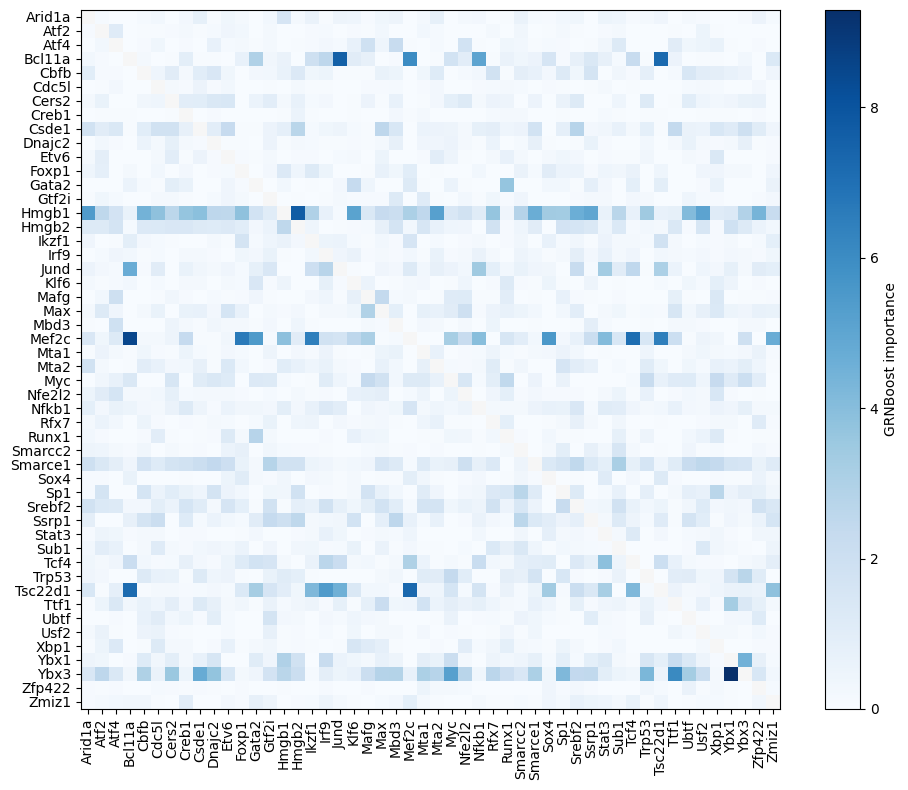

In [16]:
# Full TF × target importance matrix
heatmap_df = network_real.pivot(
    index="TF",
    columns="target",
    values="importance"
).fillna(0.0)

heatmap_df = heatmap_df.sort_index(axis=0).sort_index(axis=1)

threshold = 0

# Mask values below threshold → white
mask_below = heatmap_df < threshold

# Mask diagonal → light gray
diag_mask = pd.DataFrame(
    np.eye(len(heatmap_df), dtype=bool),
    index=heatmap_df.index,
    columns=heatmap_df.columns,
)

# Combined mask
mask = mask_below | diag_mask

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(10, 8))

# Base colormap (for significant edges only)
cmap = plt.cm.Blues.copy()
cmap.set_bad(color="white")       # below threshold
cmap.set_under(color="white")

# Show matrix with mask
im = ax.imshow(
    heatmap_df,
    cmap=cmap,
    vmin=threshold,
    aspect="auto",
)
# Mask everything except the diagonal
diag_only = np.ma.masked_where(~diag_mask.values, diag_mask.values)

ax.imshow(
    diag_only,
    cmap=mcolors.ListedColormap(["#F6F6F6"]),
    interpolation="none",
    alpha=1.0,
)

# Ticks
ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_xticklabels(heatmap_df.columns, rotation=90)
ax.set_yticklabels(heatmap_df.index)

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("GRNBoost importance")

plt.tight_layout()
plt.show()


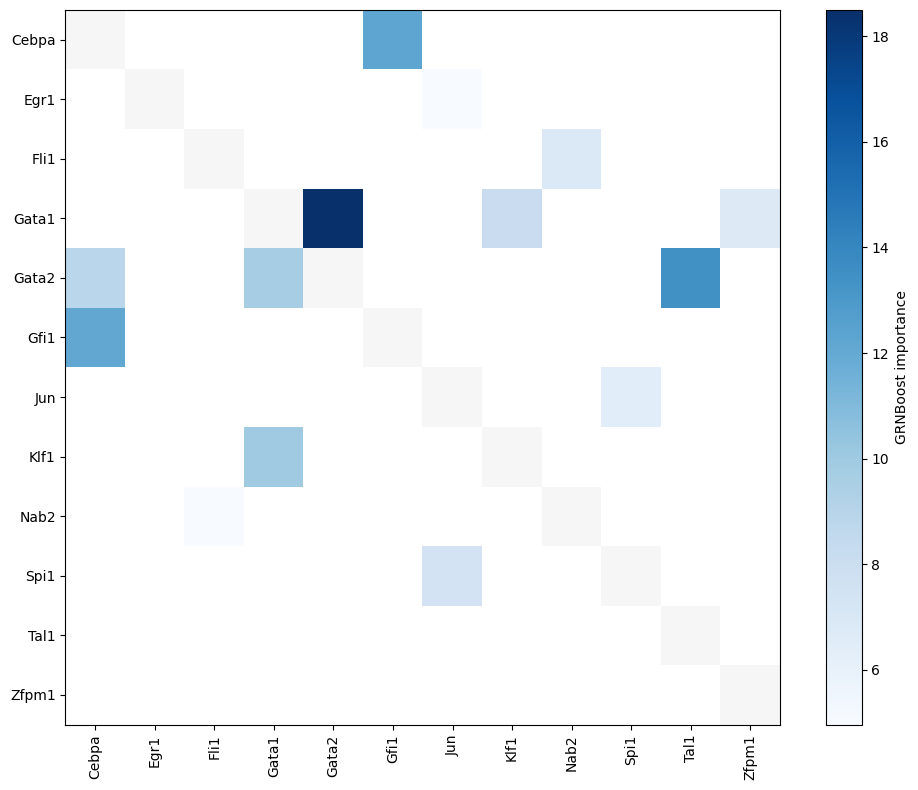

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ============================================================
# 1. Build full TF × target importance matrix
# ============================================================

heatmap_df = (
    network
    .pivot(index="TF", columns="target", values="importance")
    .fillna(0.0)
    .sort_index(axis=0)
    .sort_index(axis=1)
)

# ============================================================
# 2. Compute per-edge (TF, target) null thresholds
# ============================================================

edge_threshold_df = (
    null_df
    .groupby(["TF", "target"])["importance"]
    .quantile(0.95)
    .unstack()
)

# Align to full matrix; edges never seen in nulls → +inf (always masked)
edge_threshold_df = (
    edge_threshold_df
    .reindex(index=heatmap_df.index, columns=heatmap_df.columns)
    .fillna(np.inf)
)

# ============================================================
# 3. Masks
# ============================================================

# Below their own edge-specific threshold → white
mask_below = heatmap_df < edge_threshold_df

# Diagonal mask → light gray
diag_mask = pd.DataFrame(
    np.eye(len(heatmap_df), dtype=bool),
    index=heatmap_df.index,
    columns=heatmap_df.columns,
)

# ============================================================
# 4. Prepare plot matrix
# ============================================================

plot_matrix = heatmap_df.mask(mask_below)

# ============================================================
# 5. Plot
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

cmap = plt.cm.Blues.copy()
cmap.set_bad("white")

im = ax.imshow(
    plot_matrix,
    cmap=cmap,
    aspect="auto",
)

# ---- diagonal overlay (only diagonal, not full cover) ----
diag_only = np.ma.masked_where(~diag_mask.values, diag_mask.values)
ax.imshow(
    diag_only,
    cmap=mcolors.ListedColormap(["#F6F6F6"]),
    interpolation="none",
)

# ---- ticks & labels ----
ax.set_xticks(np.arange(len(plot_matrix.columns)))
ax.set_yticks(np.arange(len(plot_matrix.index)))
ax.set_xticklabels(plot_matrix.columns, rotation=90)
ax.set_yticklabels(plot_matrix.index)

# ---- colorbar ----
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("GRNBoost importance")

plt.tight_layout()
plt.show()


## Figure 1 network and five gene cascade

# Figure 1 network

In [8]:
%%capture
import os
gene_names = [f"gene_{i}_mRNA" for i in np.arange(1,15)]
path_to_simulations = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/figure_4/"
prefix = "df_rows_0_0_0_0_0_0_0_0_0_0_0_0_0_0"
path_to_plot_data = ""
list_simulations = [
    f.path
    for f in os.scandir(path_to_simulations)
    if f.is_file() and f.name.startswith(prefix)
]
path_to_plot_data = "/home/gzu5140/Keerthana_b1042/grnInference/plot_data/f1_scores/"

for id, path in enumerate(list_simulations):
    df = pd.read_csv(path)
    df_5_gene_network = df[df['time_step'] == 1]
    gene_names = [f"gene_{i}_mRNA" for i in np.arange(1,15)]
    df_5_gene_network = df_5_gene_network[gene_names]
    X = df_5_gene_network.to_numpy(dtype=np.float64)

    tf_names = list(gene_names)

    network = grnboost2(
        expression_data=X,
        gene_names=tf_names,
        tf_names=tf_names,
        verbose=True,
        seed = 101010
    )
    network.to_csv(f"{path_to_plot_data}/grn_boost_figure_1_network_inference_{id}.csv")

In [2]:
import os
gene_names = [f"gene_{i}_mRNA" for i in np.arange(1,15)]
path_to_simulations = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/figure_4/"
prefix = "df_rows_0_0_0_0_0_0_0_0_0_0_0_0_0_0"
path_to_plot_data = ""
list_simulations = [
    f.path
    for f in os.scandir(path_to_simulations)
    if f.is_file() and f.name.startswith(prefix)
]
path_to_plot_data = "/home/gzu5140/Keerthana_b1042/grnInference/plot_data/f1_scores/"
path = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/figure_4/df_rows_0_0_0_0_0_0_0_0_0_0_0_0_0_0_15122025_072423_ncells_6000_figure_1_network_0_1_eb90c181.csv"
df = pd.read_csv(path)
df = df[df['time_step'] == 1]
gene_names = [f"gene_{i}_mRNA" for i in np.arange(1,15)]
df = df[gene_names]
X = df.to_numpy(dtype=np.float64)
tf_names = list(gene_names)
network_f1 = grnboost2(
    expression_data=X,
    gene_names=tf_names,
    tf_names=tf_names,
    verbose=True,
    seed = 101010
)
network_f1.to_csv(f"{path_to_plot_data}/grn_boost_figure_1_network_inference_best_f1.csv")

preparing dask client
parsing input
creating dask graph
13 partitions
computing dask graph
shutting down client and local cluster
finished


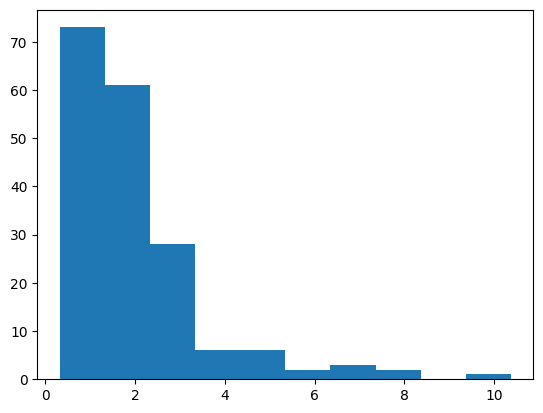

In [4]:
import matplotlib.pyplot as plt
plt.hist(network_f1['importance'])
plt.show()

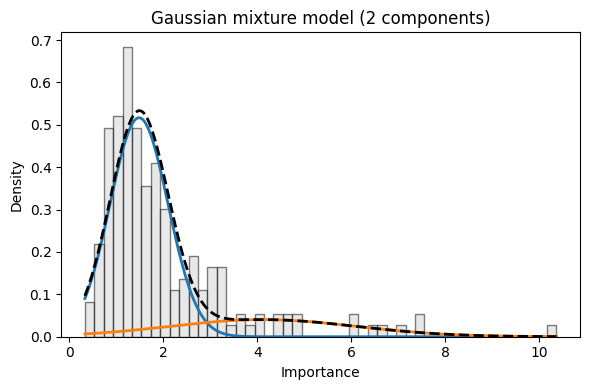

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

# data
x = network_f1["importance"].values.reshape(-1, 1)

# fit 2-component GMM
gmm = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=0
)
gmm.fit(x)

weights = gmm.weights_
means = gmm.means_.flatten()
stds = np.sqrt(gmm.covariances_.flatten())

# sort components by mean
order = np.argsort(means)
weights, means, stds = weights[order], means[order], stds[order]

x_grid = np.linspace(x.min(), x.max(), 1000)

plt.figure(figsize=(6, 4))

# histogram (density normalized)
plt.hist(
    x.flatten(),
    bins=50,
    density=True,
    alpha=0.5,
    color="lightgray",
    edgecolor="black"
)

# plot each Gaussian component
for w, mu, sigma in zip(weights, means, stds):
    plt.plot(
        x_grid,
        w * norm.pdf(x_grid, mu, sigma),
        linewidth=2
    )

# mixture density
mixture_pdf = sum(
    w * norm.pdf(x_grid, mu, sigma)
    for w, mu, sigma in zip(weights, means, stds)
)
plt.plot(x_grid, mixture_pdf, "k--", linewidth=2)

plt.xlabel("Importance")
plt.ylabel("Density")
plt.title("Gaussian mixture model (2 components)")
plt.tight_layout()
plt.show()

In [10]:
import os
gene_names = [f"gene_{i}_mRNA" for i in np.arange(1,4)]
path_to_simulations = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/three_gene_sim_all_variants/"
prefix = "df_rows_0_0_0"
path_to_plot_data = ""
list_simulations = [
    f.path
    for f in os.scandir(path_to_simulations)
    if f.is_file() and f.name.startswith(prefix) and "Fan_out_additive" in f.name
]
path_to_plot_data = "/home/gzu5140/Keerthana_b1042/grnInference/plot_data/f1_scores_3_gene/"
os.makedirs(path_to_plot_data, exist_ok = True)
for id, path in enumerate(list_simulations):
    df = pd.read_csv(path)
    df_5_gene_network = df[df['time_step'] == 1]
    gene_names = [f"gene_{i}_mRNA" for i in np.arange(1,4)]
    df_5_gene_network = df_5_gene_network[gene_names]
    X = df_5_gene_network.to_numpy(dtype=np.float64)

    tf_names = list(gene_names)

    network = grnboost2(
        expression_data=X,
        gene_names=tf_names,
        tf_names=tf_names,
        verbose=True,
        seed = 101010
    )
    network.to_csv(f"{path_to_plot_data}/grn_boost_fan_out_network_inference_best_{id}.csv")

preparing dask client


/home/gzu5140/.conda/envs/grnboost310/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39771 instead
  warnings.warn(


parsing input
creating dask graph
5 partitions
computing dask graph
shutting down client and local cluster
finished
preparing dask client


/home/gzu5140/.conda/envs/grnboost310/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39647 instead
  warnings.warn(


parsing input
creating dask graph
5 partitions
computing dask graph
shutting down client and local cluster
finished
preparing dask client


...

parsing input
creating dask graph
5 partitions
computing dask graph
shutting down client and local cluster
finished
preparing dask client


/home/gzu5140/.conda/envs/grnboost310/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40333 instead
  warnings.warn(


parsing input
creating dask graph
5 partitions
computing dask graph
shutting down client and local cluster
finished
preparing dask client


/home/gzu5140/.conda/envs/grnboost310/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40899 instead
  warnings.warn(


parsing input
creating dask graph
5 partitions
computing dask graph
shutting down client and local cluster
finished


In [11]:
import os
from tqdm import tqdm
gene_names = [f"gene_{i}_mRNA" for i in np.arange(1,4)]
path_to_simulations = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/three_gene_sim_all_variants/"
prefix = "df_rows_0_0_0"
path_to_plot_data = ""
list_simulations = [
    f.path
    for f in os.scandir(path_to_simulations)
    if f.is_file() and f.name.startswith(prefix) and "Feed_forward_additive" in f.name
]
path_to_plot_data = "/home/gzu5140/Keerthana_b1042/grnInference/plot_data/f1_scores_3_gene/"
os.makedirs(path_to_plot_data, exist_ok = True)
for id, path in tqdm(enumerate(list_simulations)):
    df = pd.read_csv(path)
    df_5_gene_network = df[df['time_step'] == 1]
    gene_names = [f"gene_{i}_mRNA" for i in np.arange(1,4)]
    df_5_gene_network = df_5_gene_network[gene_names]
    X = df_5_gene_network.to_numpy(dtype=np.float64)

    tf_names = list(gene_names)

    network = grnboost2(
        expression_data=X,
        gene_names=tf_names,
        tf_names=tf_names,
        verbose=True,
        seed = 101010
    )
    network.to_csv(f"{path_to_plot_data}/grn_boost_feed_forward_network_inference_best_{id}.csv")

0it [00:00, ?it/s]

preparing dask client


/home/gzu5140/.conda/envs/grnboost310/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44339 instead
  warnings.warn(


parsing input
creating dask graph
5 partitions
computing dask graph
shutting down client and local cluster


1it [00:05,  5.94s/it]

...

finished
preparing dask client


/home/gzu5140/.conda/envs/grnboost310/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35423 instead
  warnings.warn(


parsing input
creating dask graph
5 partitions
computing dask graph
shutting down client and local cluster


22it [01:31,  4.14s/it]

finished


In [12]:
import os
from tqdm import tqdm
gene_names = [f"gene_{i}_mRNA" for i in np.arange(1,4)]
path_to_simulations = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/three_gene_sim_all_variants/"
prefix = "df_rows_0_0_0"
path_to_plot_data = ""
list_simulations = [
    f.path
    for f in os.scandir(path_to_simulations)
    if f.is_file() and f.name.startswith(prefix) and "Mutual_regulation_additive" in f.name
]
path_to_plot_data = "/home/gzu5140/Keerthana_b1042/grnInference/plot_data/f1_scores_3_gene/"
os.makedirs(path_to_plot_data, exist_ok = True)
for id, path in tqdm(enumerate(list_simulations)):
    df = pd.read_csv(path)
    df_5_gene_network = df[df['time_step'] == 1]
    gene_names = [f"gene_{i}_mRNA" for i in np.arange(1,4)]
    df_5_gene_network = df_5_gene_network[gene_names]
    X = df_5_gene_network.to_numpy(dtype=np.float64)

    tf_names = list(gene_names)

    network = grnboost2(
        expression_data=X,
        gene_names=tf_names,
        tf_names=tf_names,
        verbose=True,
        seed = 101010
    )
    network.to_csv(f"{path_to_plot_data}/grn_boost_mutual_regulation_network_inference_best_{id}.csv")

0it [00:00, ?it/s]

preparing dask client


/home/gzu5140/.conda/envs/grnboost310/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36103 instead
  warnings.warn(


parsing input
creating dask graph
5 partitions
computing dask graph
shutting down client and local cluster


1it [00:05,  5.11s/it]

...

finished
preparing dask client


/home/gzu5140/.conda/envs/grnboost310/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 32917 instead
  warnings.warn(


parsing input
creating dask graph
5 partitions
computing dask graph
shutting down client and local cluster


30it [01:48,  3.61s/it]

finished


In [ ]:
%%capture
import os
gene_names = [f"gene_{i}_mRNA" for i in np.arange(1,15)]
path_to_simulations = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/figure_4/"
prefix = "df_rows_0_0_0_0_0_0_0_0_0_0_0_0_0_0"
path_to_plot_data = ""
list_simulations = [
    f.path
    for f in os.scandir(path_to_simulations)
    if f.is_file() and f.name.startswith(prefix)
]
path_to_plot_data = "/home/gzu5140/Keerthana_b1042/grnInference/plot_data/f1_scores/"

for id, path in enumerate(list_simulations):
    df = pd.read_csv(path)
    df_5_gene_network = df[df['time_step'] == 1]
    gene_names = [f"gene_{i}_mRNA" for i in np.arange(1,15)]
    df_5_gene_network = df_5_gene_network[gene_names]
    X = df_5_gene_network.to_numpy(dtype=np.float64)

    tf_names = list(gene_names)

    network = grnboost2(
        expression_data=X,
        gene_names=tf_names,
        tf_names=tf_names,
        verbose=True,
        seed = 101010
    )
    network.to_csv(f"{path_to_plot_data}/grn_boost_figure_1_network_inference_best.csv")

In [9]:
%%capture
import os
gene_names = [f"gene_{i}_mRNA" for i in np.arange(1,6)]
path_to_simulations = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_3_simulations/"
prefix = "df_rows_0_0_0_0_0"

list_simulations = [
    f.path
    for f in os.scandir(path_to_simulations)
    if f.is_file() and f.name.startswith(prefix) and "rep" in f.name
]

path_to_plot_data = "/home/gzu5140/Keerthana_b1042/grnInference/plot_data/f1_scores/"

for id, path in enumerate(list_simulations):
    df = pd.read_csv(path)
    df_5_gene_network = df[df['time_step'] == 1]
    gene_names = [f"gene_{i}_mRNA" for i in np.arange(1,6)]
    df_5_gene_network = df_5_gene_network[gene_names]
    X = df_5_gene_network.to_numpy(dtype=np.float64)

    tf_names = list(gene_names)

    network = grnboost2(
        expression_data=X,
        gene_names=tf_names,
        tf_names=tf_names,
        verbose=True,
        seed = 101010
    )
    network.to_csv(f"{path_to_plot_data}/grn_boost_five_gene_cascade_inference_{id}.csv")

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
)

AUROC: 0.8184
AUPRC: 0.5274
Random AUPRC baseline: 0.0714


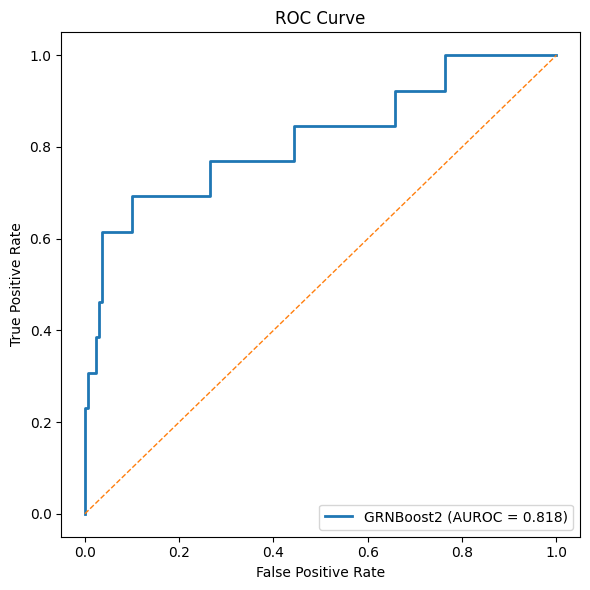

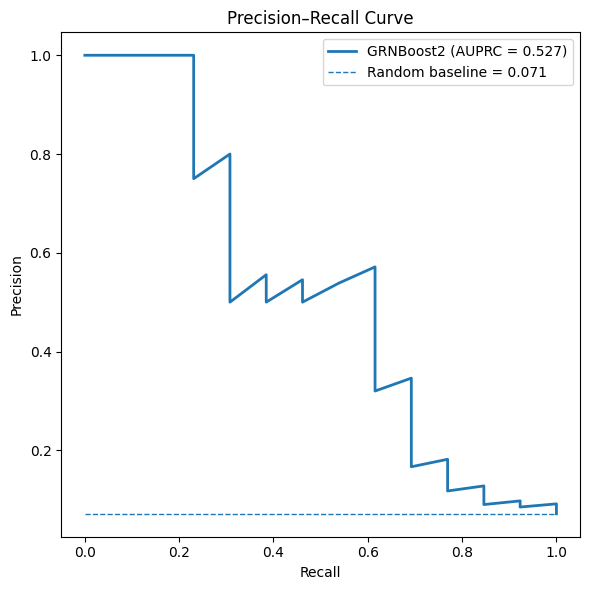

In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

# ============================================================
# 1. Load ground-truth connectivity matrix
# ============================================================

gt_path = "/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/simulation_example_input_data/connectivity_matrix_figure_1_network.txt"

# Load as numpy array
gt_matrix = np.loadtxt(gt_path, delimiter= ",")

n_genes = gt_matrix.shape[0]
genes = [f"gene_{i+1}_mRNA" for i in range(n_genes)]

gt_df = pd.DataFrame(
    gt_matrix,
    index=genes,
    columns=genes,
)

# Binary ground truth: edge exists or not
gt_binary = (gt_df.values != 0).astype(int)
np.fill_diagonal(gt_binary, 0)

# ============================================================
# 2. Build predicted score matrix from network
# ============================================================

pred_df = (
    network_f1
    .pivot(index="TF", columns="target", values="importance")
    .reindex(index=genes, columns=genes)
    .fillna(0.0)
)

np.fill_diagonal(pred_df.values, 0.0)

# ============================================================
# 3. Vectorize edges (exclude diagonal)
# ============================================================

y_true = gt_binary.flatten()
y_score = pred_df.values.flatten()

mask = ~np.eye(n_genes, dtype=bool).flatten()
y_true = y_true[mask]
y_score = y_score[mask]

# ============================================================
# 4. Compute metrics
# ============================================================

auroc = roc_auc_score(y_true, y_score)
auprc = average_precision_score(y_true, y_score)
baseline_pr = y_true.mean()

print(f"AUROC: {auroc:.4f}")
print(f"AUPRC: {auprc:.4f}")
print(f"Random AUPRC baseline: {baseline_pr:.4f}")

# ============================================================
# 5. ROC curve
# ============================================================

fpr, tpr, _ = roc_curve(y_true, y_score)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"GRNBoost2 (AUROC = {auroc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ============================================================
# 6. Precision–Recall curve
# ============================================================

precision, recall, _ = precision_recall_curve(y_true, y_score)

plt.figure(figsize=(6, 6))
plt.plot(recall, precision, linewidth=2, label=f"GRNBoost2 (AUPRC = {auprc:.3f})")
plt.hlines(
    baseline_pr,
    xmin=0,
    xmax=1,
    linestyles="--",
    linewidth=1,
    label=f"Random baseline = {baseline_pr:.3f}",
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score
import re

# Candidate thresholds = unique sorted scores
thresholds = np.unique(y_score)[::-1]

rows = []

for t in thresholds:
    y_pred = (y_score >= t).astype(int)

    if y_pred.sum() == 0:
        continue

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    rows.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "n_edges": y_pred.sum(),
    })

df_metrics = pd.DataFrame(rows)
df_metrics = df_metrics.sort_values(by="n_edges")
best_f1_row = df_metrics.loc[df_metrics["f1"].idxmax()]
best_f1_row


threshold     4.477021
precision     0.571429
recall        0.615385
f1            0.592593
n_edges      14.000000
Name: 13, dtype: float64

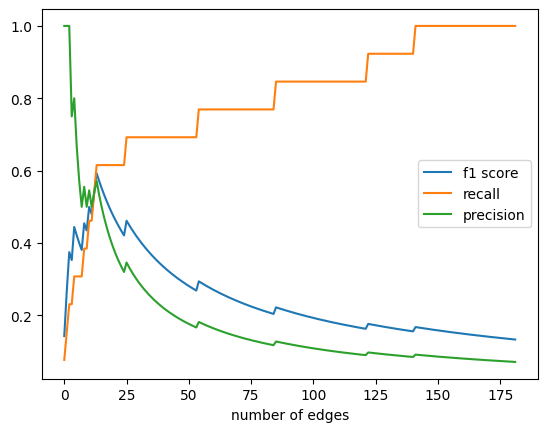

In [10]:
plt.plot(df_metrics["f1"], label = "f1 score")
plt.plot(df_metrics["recall"], label = "recall")
plt.plot(df_metrics["precision"], label = "precision")
plt.xlabel("number of edges")
plt.legend()
plt.show()

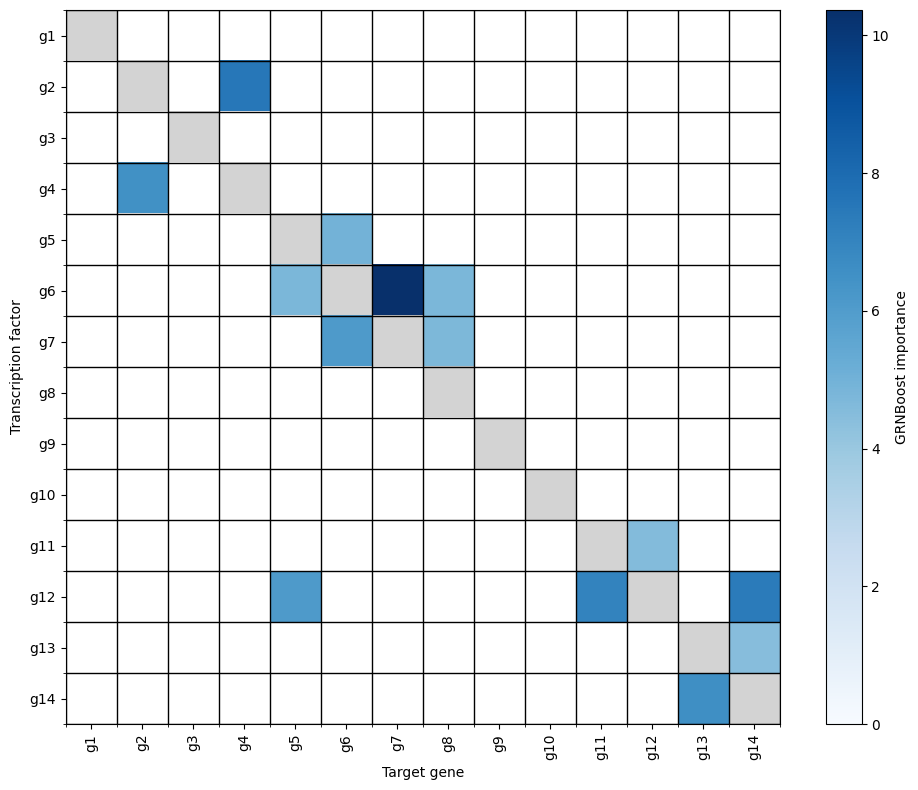

In [11]:
import matplotlib.colors as mcolors
threshold = 4.47
# Ensure correct column names
network_f1 = network_f1.rename(columns={
    "TF": "tf",
    "target": "target",
    "importance": "importance"
})

# Pivot to TF × target matrix
heatmap_df = network_f1.pivot(
    index="tf",
    columns="target",
    values="importance"
)

# Replace missing edges with 0
heatmap_df = heatmap_df.fillna(0.0)


def to_g_label(name):
    m = re.search(r'(\d+)', str(name))
    return f"g{m.group(1)}" if m else name

heatmap_df = heatmap_df.rename(
    columns=to_g_label,
    index=to_g_label
)

def g_key(name):
    m = re.search(r'(\d+)', str(name))
    return int(m.group(1)) if m else float("inf")

heatmap_df = heatmap_df.sort_index(
    key=lambda idx: [g_key(x) for x in idx]
).sort_index(
    axis=1,
    key=lambda cols: [g_key(x) for x in cols]
)


mask_below = heatmap_df < threshold

# Diagonal mask → light gray
diag_mask = pd.DataFrame(
    np.eye(len(heatmap_df), dtype=bool),
    index=heatmap_df.index,
    columns=heatmap_df.columns,
)

# ============================================================
# 4. Prepare plot matrix
# ============================================================

plot_matrix = heatmap_df.mask(mask_below)

# ============================================================
# 5. Plot
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

cmap = plt.cm.Blues.copy()
cmap.set_bad("white")

im = ax.imshow(
    plot_matrix,
    cmap=cmap,
    aspect="auto",
    vmin = 0
)

# ---- diagonal overlay (only diagonal, not full cover) ----
diag_only = np.ma.masked_where(~diag_mask.values, diag_mask.values)
ax.imshow(
    diag_only,
    cmap=mcolors.ListedColormap(["lightgray"]),
    interpolation="none",
    vmin=0
)

# Axis labels
ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_yticks(np.arange(len(heatmap_df.index)))

ax.set_xticklabels(heatmap_df.columns, rotation=90)
ax.set_yticklabels(heatmap_df.index)

ax.set_xticks(np.arange(-0.5, plot_matrix.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, plot_matrix.shape[0], 1), minor=True)

ax.grid(
    which="minor",
    color="black",
    linestyle="-",
    linewidth=1,
)

ax.set_xlabel("Target gene")
ax.set_ylabel("Transcription factor")

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("GRNBoost importance")

plt.tight_layout()
plt.show()

In [53]:
plot_matrix.to_csv("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_3_02012026/grnboost2_fig_1_inference.csv")

## Five gene cascade

In [2]:
gene_names = [f"gene_{i}_mRNA" for i in np.arange(1,4)]
df = pd.read_csv('/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/three_gene_sim_all_variants/df_rows_0_0_0_13122025_031632_ncells_6000_Fan_out_additive_2_0_c69c7586.csv')

df_5_gene_network = df[df['time_step'] == 1]
df_5_gene_network = df_5_gene_network[gene_names]
X = df_5_gene_network.to_numpy(dtype=np.float64)

tf_names = list(gene_names)

network = grnboost2(
    expression_data=X,
    gene_names=tf_names,
    tf_names=tf_names,
    verbose=True,
    seed = 101010
)
network

preparing dask client


/home/gzu5140/.conda/envs/grnboost310/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45887 instead
  warnings.warn(


parsing input
creating dask graph
5 partitions
computing dask graph
shutting down client and local cluster
finished


,TF,target,importance
1,gene_2_mRNA,gene_3_mRNA,19.162947
0,gene_2_mRNA,gene_1_mRNA,17.076023
1,gene_3_mRNA,gene_2_mRNA,15.871436
0,gene_1_mRNA,gene_2_mRNA,11.128564
1,gene_3_mRNA,gene_1_mRNA,10.923977
0,gene_1_mRNA,gene_3_mRNA,7.837053


In [2]:
gene_names = [f"gene_{i}_mRNA" for i in np.arange(1,6)]
df = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_3_simulations/df_rows_0_0_0_0_0_03122025_221647_ncells_6000_Five_gene_cascade_fixed_K_0_7_6a281f3f.csv")

df_5_gene_network = df[df['time_step'] == 20]
df_5_gene_network = df_5_gene_network[gene_names]
X = df_5_gene_network.to_numpy(dtype=np.float64)

tf_names = list(gene_names)

network = grnboost2(
    expression_data=X,
    gene_names=tf_names,
    tf_names=tf_names,
    verbose=True,
    seed = 101010
)

network.to_csv("/home/gzu5140/Keerthana_b1042/grnInference/plots/figure_3_10012026/fig_3_network_grnboost_network.csv")

preparing dask client
parsing input
creating dask graph
13 partitions
computing dask graph
shutting down client and local cluster
finished


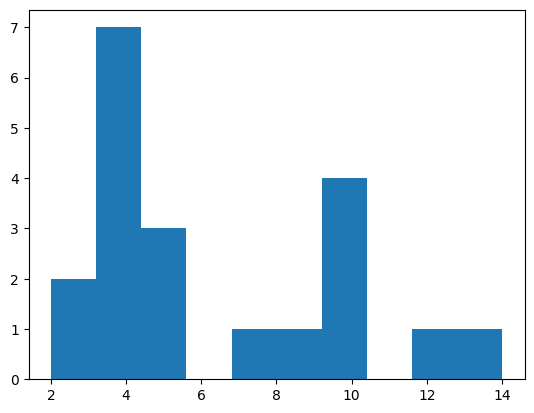

In [3]:
import matplotlib.pyplot as plt
plt.hist(network['importance'])
plt.show()

AUROC: 0.9375
AUPRC: 0.8167
Random AUPRC baseline: 0.2000


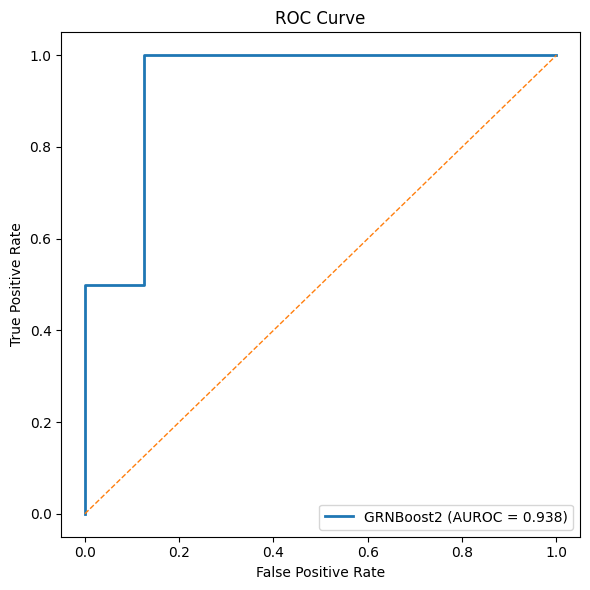

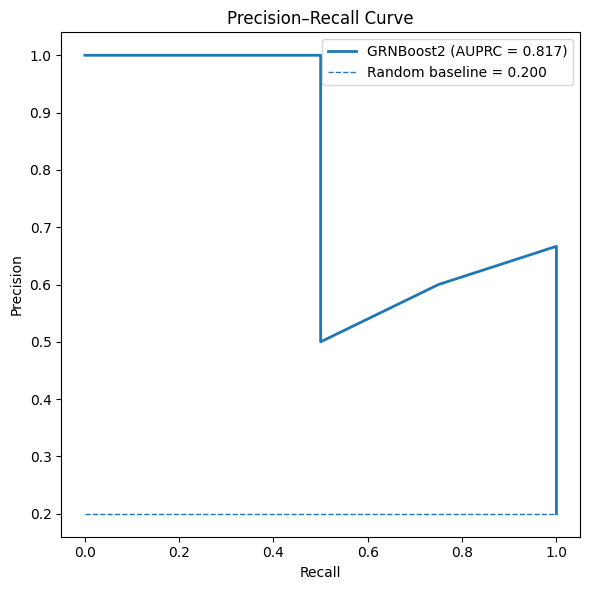

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

# ============================================================
# 1. Load ground-truth connectivity matrix
# ============================================================

gt_path = "/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/simulation_example_input_data/connectivity_matrix_5_gene_linear_cascade.txt"

# Load as numpy array
gt_matrix = np.loadtxt(gt_path, delimiter= ",")

n_genes = gt_matrix.shape[0]
genes = [f"gene_{i+1}_mRNA" for i in range(n_genes)]

gt_df = pd.DataFrame(
    gt_matrix,
    index=genes,
    columns=genes,
)

# Binary ground truth: edge exists or not
gt_binary = (gt_df.values != 0).astype(int)
np.fill_diagonal(gt_binary, 0)

# ============================================================
# 2. Build predicted score matrix from network
# ============================================================

pred_df = (
    network
    .pivot(index="TF", columns="target", values="importance")
    .reindex(index=genes, columns=genes)
    .fillna(0.0)
)

np.fill_diagonal(pred_df.values, 0.0)

# ============================================================
# 3. Vectorize edges (exclude diagonal)
# ============================================================

y_true = gt_binary.flatten()
y_score = pred_df.values.flatten()

mask = ~np.eye(n_genes, dtype=bool).flatten()
y_true = y_true[mask]
y_score = y_score[mask]

# ============================================================
# 4. Compute metrics
# ============================================================

auroc = roc_auc_score(y_true, y_score)
auprc = average_precision_score(y_true, y_score)
baseline_pr = y_true.mean()

print(f"AUROC: {auroc:.4f}")
print(f"AUPRC: {auprc:.4f}")
print(f"Random AUPRC baseline: {baseline_pr:.4f}")

# ============================================================
# 5. ROC curve
# ============================================================

fpr, tpr, _ = roc_curve(y_true, y_score)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"GRNBoost2 (AUROC = {auroc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ============================================================
# 6. Precision–Recall curve
# ============================================================

precision, recall, _ = precision_recall_curve(y_true, y_score)

plt.figure(figsize=(6, 6))
plt.plot(recall, precision, linewidth=2, label=f"GRNBoost2 (AUPRC = {auprc:.3f})")
plt.hlines(
    baseline_pr,
    xmin=0,
    xmax=1,
    linestyles="--",
    linewidth=1,
    label=f"Random baseline = {baseline_pr:.3f}",
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [19]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score
import re

# Candidate thresholds = unique sorted scores
thresholds = np.unique(y_score)[::-1]

rows = []

for t in thresholds:
    y_pred = (y_score >= t).astype(int)

    if y_pred.sum() == 0:
        continue

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    rows.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "n_edges": y_pred.sum(),
    })

df_metrics = pd.DataFrame(rows)
df_metrics = df_metrics.sort_values(by="n_edges")
best_f1_row = df_metrics.loc[df_metrics["f1"].idxmax()]
best_f1_row


threshold    9.343009
precision    0.666667
recall       1.000000
f1           0.800000
n_edges      6.000000
Name: 5, dtype: float64

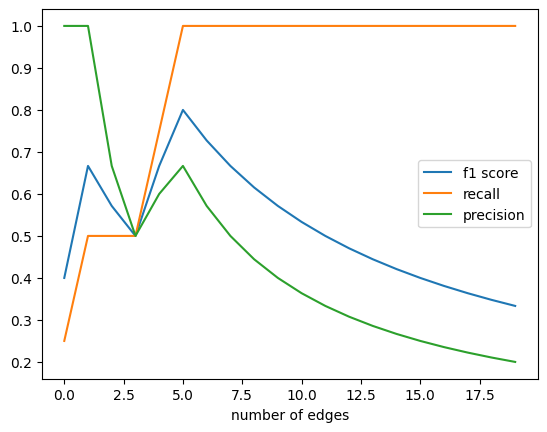

In [20]:
plt.plot(df_metrics["f1"], label = "f1 score")
plt.plot(df_metrics["recall"], label = "recall")
plt.plot(df_metrics["precision"], label = "precision")
plt.xlabel("number of edges")
plt.legend()
plt.show()

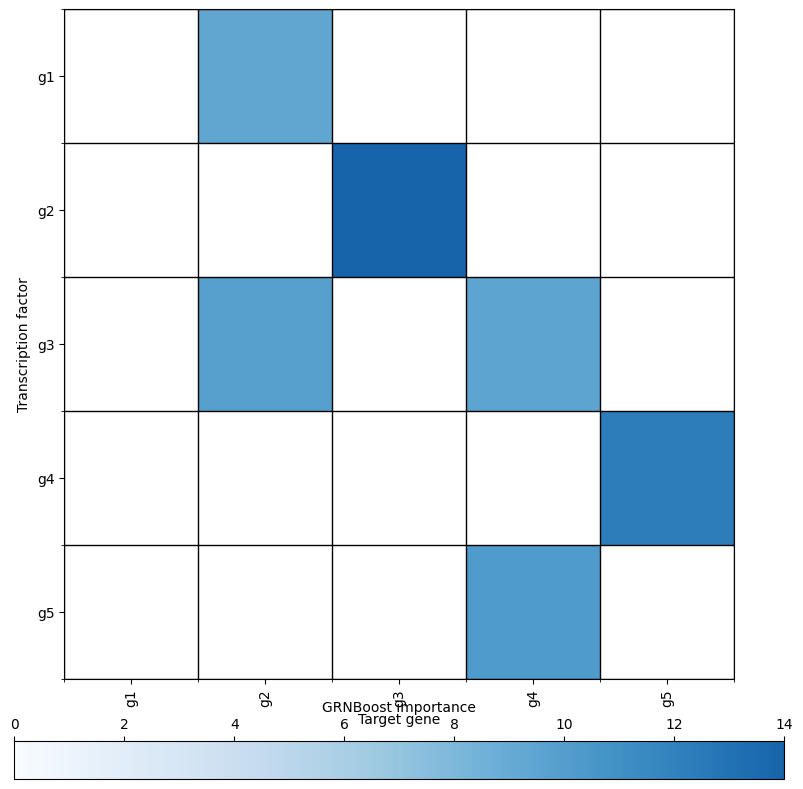

In [30]:
import matplotlib.colors as mcolors
threshold = 9.3430
# Ensure correct column names
network = network.rename(columns={
    "TF": "tf",
    "target": "target",
    "importance": "importance"
})

# Pivot to TF × target matrix
heatmap_df = network.pivot(
    index="tf",
    columns="target",
    values="importance"
)

# Replace missing edges with 0
heatmap_df = heatmap_df.fillna(0.0)

def to_g_label(name):
    m = re.search(r'(\d+)', str(name))
    return f"g{m.group(1)}" if m else name

heatmap_df = heatmap_df.rename(
    columns=to_g_label,
    index=to_g_label
)

def g_key(name):
    m = re.search(r'(\d+)', str(name))
    return int(m.group(1)) if m else float("inf")

heatmap_df = heatmap_df.sort_index(
    key=lambda idx: [g_key(x) for x in idx]
).sort_index(
    axis=1,
    key=lambda cols: [g_key(x) for x in cols]
)


mask_below = heatmap_df < threshold

# Diagonal mask → light gray
diag_mask = pd.DataFrame(
    np.eye(len(heatmap_df), dtype=bool),
    index=heatmap_df.index,
    columns=heatmap_df.columns,
)

# ============================================================
# 4. Prepare plot matrix
# ============================================================

plot_matrix = heatmap_df.mask(mask_below)

# ============================================================
# 5. Plot
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def make_reds_blues_colormap(vmin=-0.05, vmax=0.18):
    """Custom red–white–blue colormap with pure white at 0, asymmetric."""
    # Calculate where 0 falls in the range [vmin, vmax]
    zero_position = max(0, (0 - vmin) / (vmax - vmin))
    
    # Number of colors for each segment (proportional to range)
    n_total = 256
    n_reds = int(zero_position * n_total)  # colors from vmin to 0
    n_blues = n_total - n_reds  # colors from 0 to vmax
    
    # Calculate intensity based on actual distance from zero
    # For reds: map from vmin to 0, so max intensity at vmin
    red_intensity = abs(vmin) / max(abs(vmin), abs(vmax))  # 0.05/0.18 ≈ 0.28
    # For blues: map from 0 to vmax, so max intensity at vmax  
    blue_intensity = abs(vmax) / max(abs(vmin), abs(vmax))  # 0.18/0.18 = 1.0
    
    # Create color arrays with scaled intensities
    reds = plt.cm.Reds(np.linspace(0.8 * red_intensity, 0, n_reds))  # scaled dark to light red
    whites = np.ones((1, 4))  # pure white at 0
    blues = plt.cm.Blues(np.linspace(0, 0.8 * blue_intensity, n_blues))  # light to scaled dark blue
    
    colors = np.vstack((reds, whites, blues))
    return LinearSegmentedColormap.from_list('RedsBlues', colors)

vmin = np.min(plot_matrix)
vmax = np.max(plot_matrix)

cmap =  make_reds_blues_colormap(vmin=vmin, vmax=vmax)

cmap.set_bad("white")

im = ax.imshow(
    plot_matrix,
    cmap=cmap,
    aspect="auto",
    vmin = 0
)

# ---- diagonal overlay (only diagonal, not full cover) ----
diag_only = np.ma.masked_where(~diag_mask.values, diag_mask.values)
ax.imshow(
    diag_only,
    cmap=mcolors.ListedColormap(["white"]),
    interpolation="none",
    vmin=0
)

# Axis labels
ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_yticks(np.arange(len(heatmap_df.index)))

ax.set_xticklabels(heatmap_df.columns, rotation=90)
ax.set_yticklabels(heatmap_df.index)

ax.set_xticks(np.arange(-0.5, plot_matrix.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, plot_matrix.shape[0], 1), minor=True)

ax.grid(
    which="minor",
    color="black",
    linestyle="-",
    linewidth=1,
)

ax.set_xlabel("Target gene")
ax.set_ylabel("Transcription factor")

# Colorbar
cbar = plt.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.08,          # space between plot and colorbar
    fraction=0.05      # thickness of colorbar
)

cbar.ax.xaxis.set_label_position("top")
cbar.ax.xaxis.tick_top()
cbar.set_label("GRNBoost importance")
cbar.set_label("GRNBoost importance")
plt.tight_layout()
plt.show()

In [60]:
plot_matrix.to_csv("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_3_02012026/grnboost2_five_gene_inference.csv")